In [1]:
import pandas as pd

print("Pandas working!")

Pandas working!


In [2]:
import os
print(os.getcwd())

C:\Users\user


In [1]:
import pandas as pd

df = pd.read_csv('C:/Users/user/Downloads/bank_customer.csv')

print(df.shape)
df.head()

(10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
df.isnull().sum()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 1.0 MB


In [3]:
from scipy.stats import chi2_contingency

contingency_country = pd.crosstab(df['country'], df['churn'])
print(contingency_country)

chi2, p_value, dof, expected = chi2_contingency(contingency_country)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.10f}")

churn       0    1
country           
France   4204  810
Germany  1695  814
Spain    2064  413

Chi-square statistic: 301.26
P-value: 0.0000000000


In [4]:
contingency_products = pd.crosstab(df['products_number'], df['churn'])
print(contingency_products)

chi2_p, p_value_p, dof_p, expected_p = chi2_contingency(contingency_products)
print(f"\nChi-square statistic: {chi2_p:.2f}")
print(f"P-value: {p_value_p:.10f}")

churn               0     1
products_number            
1                3675  1409
2                4242   348
3                  46   220
4                   0    60

Chi-square statistic: 1503.63
P-value: 0.0000000000


C:\Users\user\AppData\Local\Temp\ipykernel_15320\2991945284.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_churn.index, y=country_churn.values, ax=axes[0], palette='Blues_d')
C:\Users\user\AppData\Local\Temp\ipykernel_15320\2991945284.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_churn.index, y=product_churn.values, ax=axes[1], palette='Reds_d')


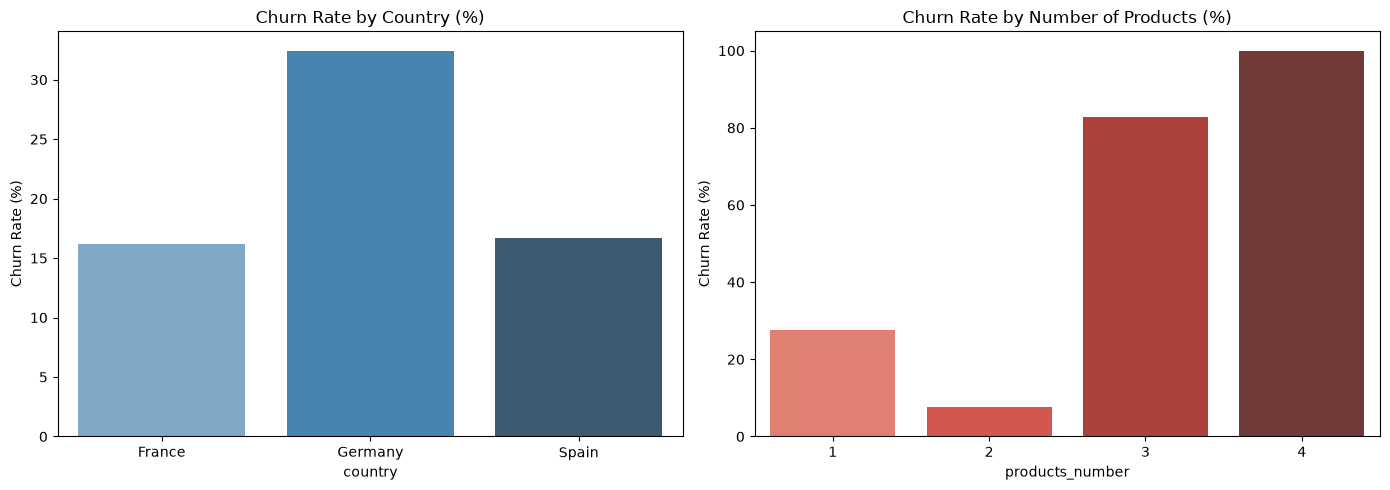

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Churn rate by country
country_churn = df.groupby('country')['churn'].mean() * 100
sns.barplot(x=country_churn.index, y=country_churn.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Churn Rate by Country (%)')
axes[0].set_ylabel('Churn Rate (%)')

# Churn rate by products_number
product_churn = df.groupby('products_number')['churn'].mean() * 100
sns.barplot(x=product_churn.index, y=product_churn.values, ax=axes[1], palette='Reds_d')
axes[1].set_title('Churn Rate by Number of Products (%)')
axes[1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('churn_charts.png', dpi=150)  # saves the image for your GitHub readme
plt.show()